In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2
from imports import *


In [2]:
from config import dir_config
from src.utils import pmf_utils, classification_utils

raw_dir = Path(dir_config.data.raw)
processed_dir = Path(dir_config.data.processed)

filtered_data = pd.read_csv(Path(processed_dir, "processed_all_data_accu_60_filtered.csv"), index_col=None)
processed_metadata = pd.read_csv(Path(processed_dir, "processed_metadata_all_data_accu_60.csv"), index_col=None)


In [3]:
subjects_map, grp_indices = classification_utils.get_subject_classification_ids(processed_metadata)

PD subjects with ON+OFF sessions: 41
PD subjects with UPDRS subtype: 22
All PD subjects:           41
  Tremor dominant:         11 	 ['P3' 'P6' 'P7' 'P11' 'P12' 'P17' 'P18' 'P19' 'P29' 'P31' 'P32']
  Brady dominant:          10 	 ['P1' 'P4' 'P9' 'P13' 'P20' 'P22' 'P23' 'P28' 'P33' 'P34']
  Intermediate:            1 	 ['P24']
HC subjects:               18 	 ['HC1' 'HC3' 'HC6' 'HC7' 'HC8' 'HC9' 'HC12' 'HC13' 'AV' 'BC' 'BF' 'EM'
 'ES' 'GF' 'GP' 'JA' 'MRM' 'SY']


## Plot group-wise psychometric function

In [4]:
def new_accumulators():
    """Empty accumulators for positive-prior and equal-prior psychometric data."""
    return {k: {"coh": [], "psych": [], "model": [], "x_hat": [], "y_hat": []} for k in ("pos", "eq")}


def collect_psych(data, accum):
    """Fit psychometric data for both color conditions and append to accum."""
    for key, color_val in [("pos", 1), ("eq", 0)]:
        coh, psych, model, x_hat, y_hat = pmf_utils.get_psychometric_data(data[data["color"] == color_val])
        for field, val in zip(["coh", "psych", "model", "x_hat", "y_hat"], [coh, psych, model, x_hat, y_hat]):
            accum[key][field].append(val)


def plot_mean_psych(ax, accum, pos_color, eq_color, err_style):
    """Plot group-mean psychometric curve with error bars and fitted line."""
    for key, color, label in [("pos", pos_color, "Positive Prior"), ("eq", eq_color, "Equal Prior")]:
        coh_arr = np.array(accum[key]["coh"])
        psych_arr = np.array(accum[key]["psych"])
        x_hat_arr = np.array(accum[key]["x_hat"])
        mean_coh, mean_psych = np.mean(coh_arr, axis=0), np.mean(psych_arr, axis=0)
        mean_x_hat = np.mean(x_hat_arr, axis=0)
        ax.plot(mean_coh, mean_psych, color=color, ls="", marker="o", ms=12, mec="k", label=label)
        ax.errorbar(mean_coh, mean_psych, yerr=stats.sem(psych_arr, axis=0), color=color, ls="", marker="o", ms=12, mec="k", **err_style)
        fit = pmf_utils.fit_psychometric_function(mean_coh, mean_psych, trial_counts=None, model_type="logit_4")
        ax.plot(mean_x_hat, fit.predict(mean_x_hat), color=color, ls="-", lw=4)


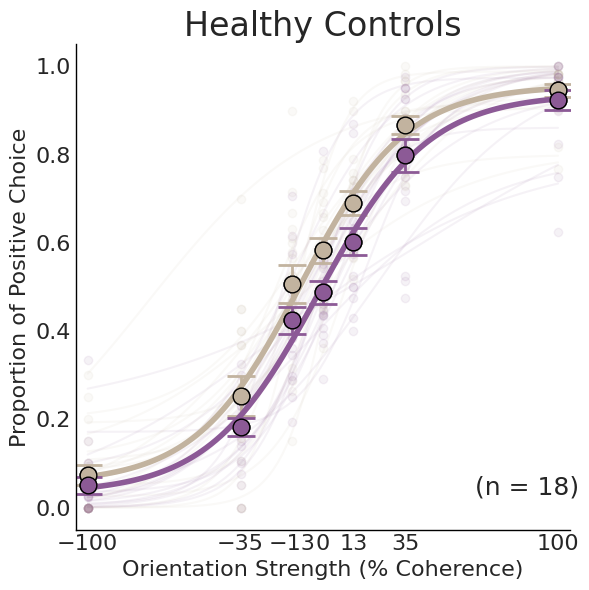

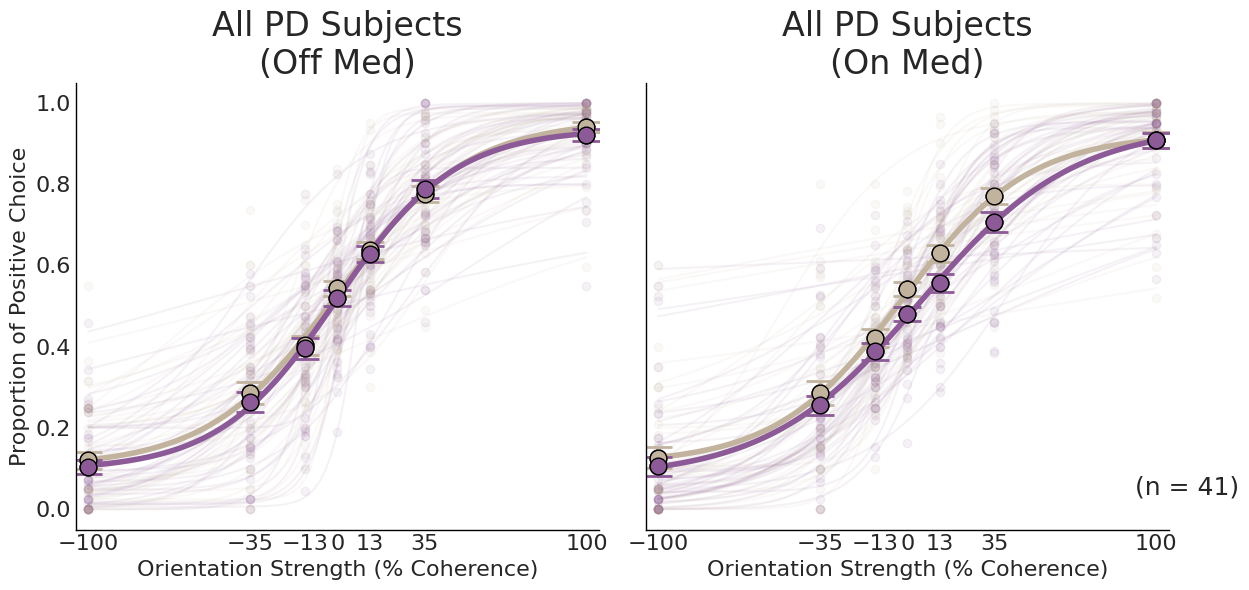

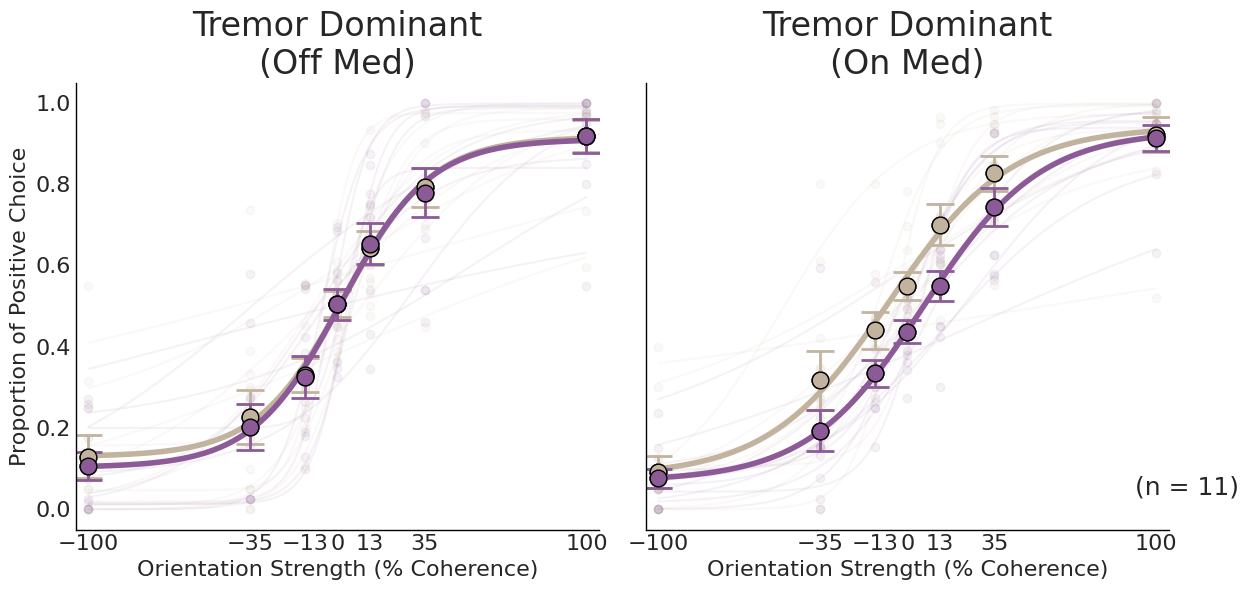

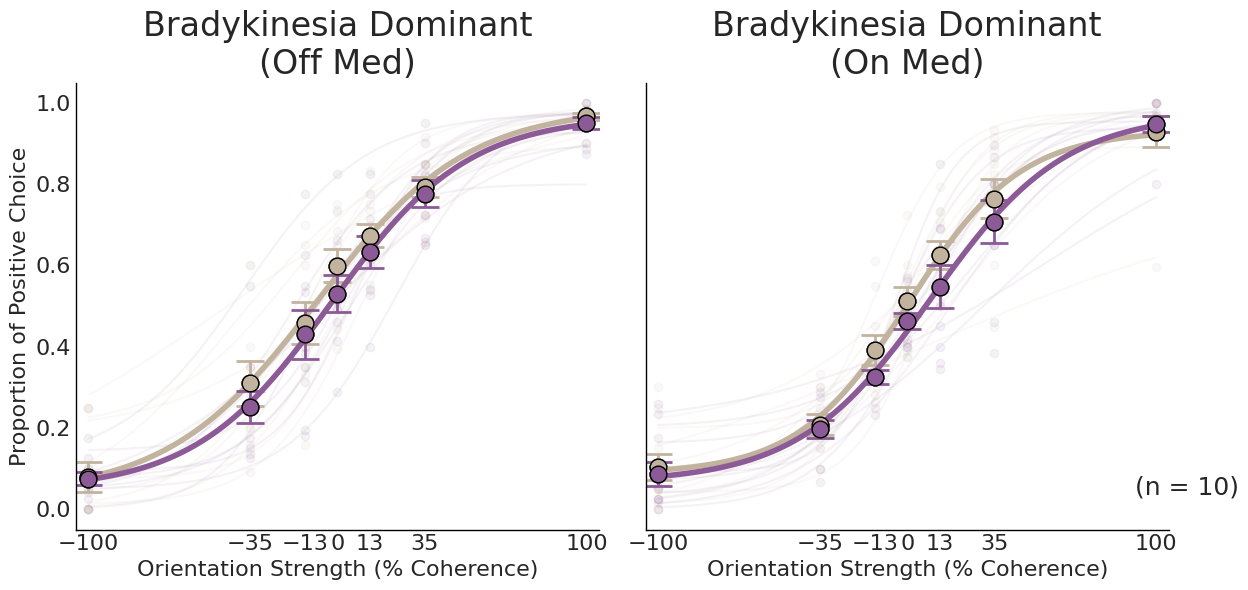

In [35]:
pos_color, eq_color = "#C2B39F", "#8C5A96"
alpha = 0.08
err_style = {"elinewidth": 2, "capsize": 10, "capthick": 2}
suptitle_map = {
    "all": "All PD Subjects",
    "tremor_dominant": "Tremor Dominant",
    "bradykinesia_dominant": "Bradykinesia Dominant",
    "healthy": "Healthy Controls",
}
for group, sub_ids in subjects_map.items():

    suptitle = suptitle_map[group]
    if group != "healthy":
        fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
    else:
        fig, _ax = plt.subplots(1, 1, figsize=(6, 6))
        ax = np.array([_ax])

    off, on = new_accumulators(), new_accumulators()
    for sid in sub_ids:
        subj_data = filtered_data[filtered_data["subject_id"] == sid].sort_values("medication")

        if group == "healthy":
            collect_psych(subj_data, off)
            for key, color in [("pos", pos_color), ("eq", eq_color)]:
                ax[0].plot(off[key]["coh"][-1], off[key]["psych"][-1], color=color, marker="o", ls="", alpha=alpha)
                ax[0].plot(off[key]["x_hat"][-1], off[key]["y_hat"][-1], color=color, ls="-", alpha=alpha)
        else:
            for med in subj_data["medication"].unique():
                accum, ax_i = (off, 0) if med == "off" else (on, 1)
                collect_psych(subj_data[subj_data["medication"] == med], accum)
                for key, color in [("pos", pos_color), ("eq", eq_color)]:
                    ax[ax_i].plot(accum[key]["coh"][-1], accum[key]["psych"][-1], color=color, marker="o", ls="", alpha=alpha)
                    ax[ax_i].plot(accum[key]["x_hat"][-1], accum[key]["y_hat"][-1], color=color, ls="-", alpha=alpha)

    if group != "healthy":
        plot_mean_psych(ax[0], off, pos_color, eq_color, err_style)
        plot_mean_psych(ax[1], on, pos_color, eq_color, err_style)
    else:
        plot_mean_psych(ax[0], off, pos_color, eq_color, err_style)

    # ── Styling ──
    for a in ax:
        a.set_xticks([-100, -35, -13, 0, 13, 35, 100])
        a.tick_params(labelsize=16)
        for sp in ["top", "right"]:
            a.spines[sp].set_visible(False)
    ax[0].set(xlabel="Orientation Strength (% Coherence)", ylabel="Proportion of Positive Choice", xlim=(-105, 105), ylim=(-0.05, 1.05), title=f"{suptitle}{'' if group == 'healthy' else '\n(Off Med)'}")
    if group != "healthy":
        ax[1].set(xlabel="Orientation Strength (% Coherence)", xlim=(-105, 105), ylim=(-0.05, 1.05), title=f"{suptitle}\n(On Med)")
        fig.text(0.95, 0.2, f"(n = {len(sub_ids)})", fontsize=18, ha="left", va="top")
    else:
        fig.text(0.8, 0.2, f"(n = {len(sub_ids)})", fontsize=18, ha="left", va="top")
    fig.tight_layout()


## Statistical tests on PMF params

In [6]:
psych_columns = [
    "positive_psych_alpha",
    "positive_psych_beta",
    "equal_psych_alpha",
    "equal_psych_beta",
    "positive_bias",
    "equal_bias",
]

psych_params = processed_metadata[psych_columns]


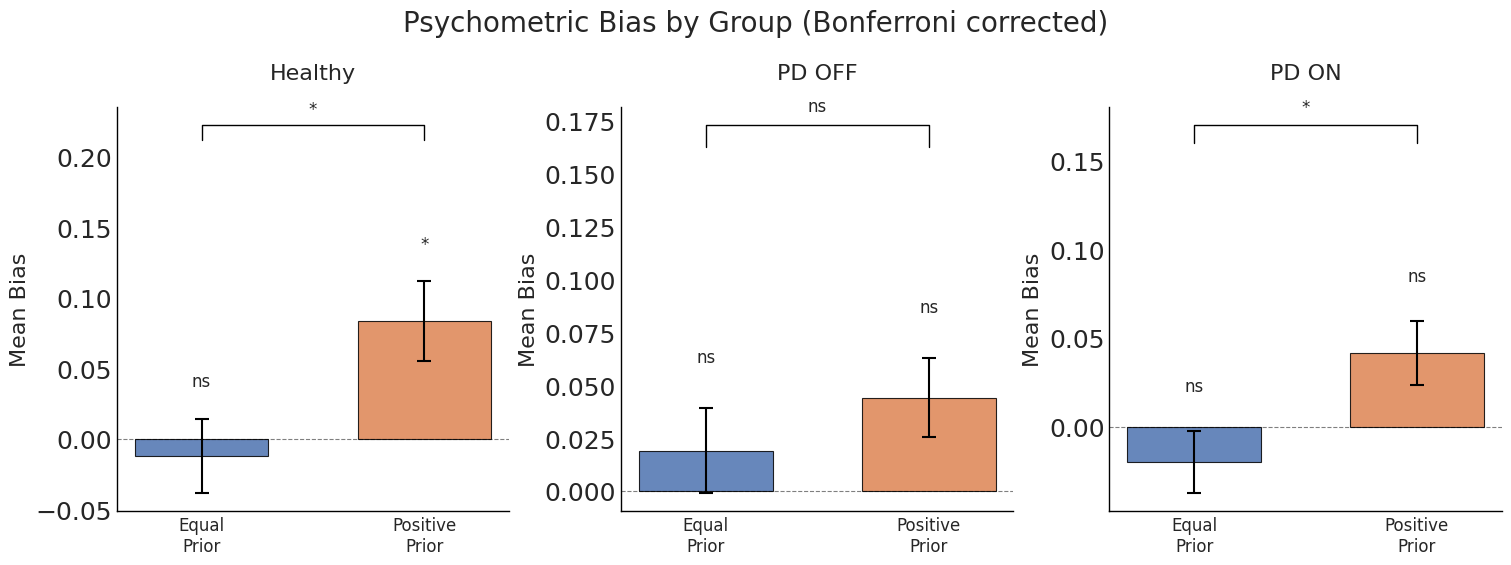

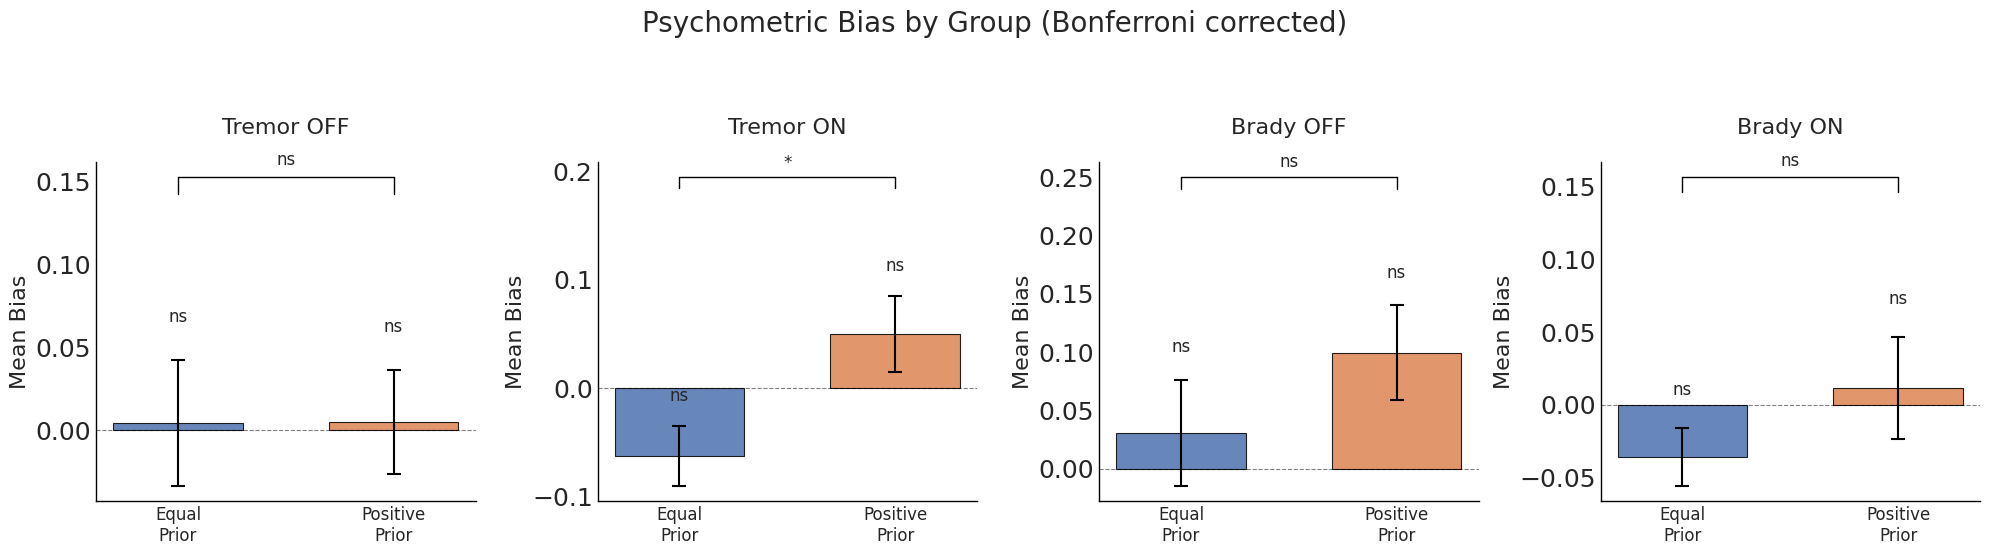

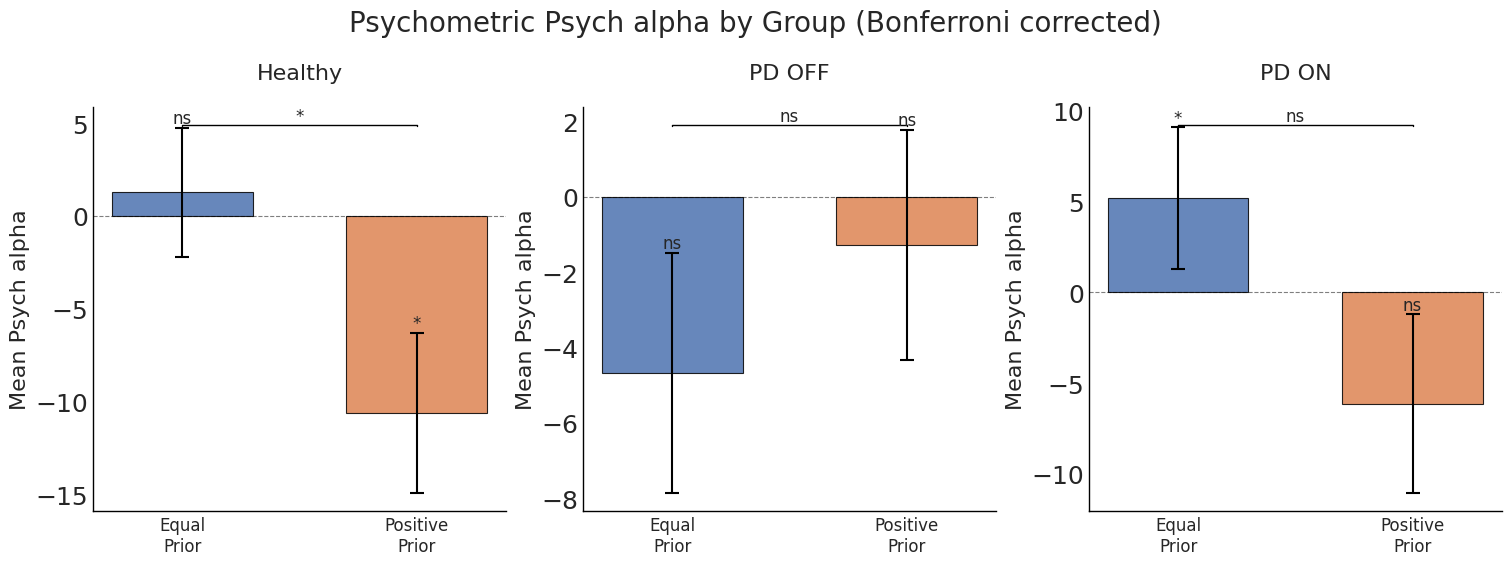

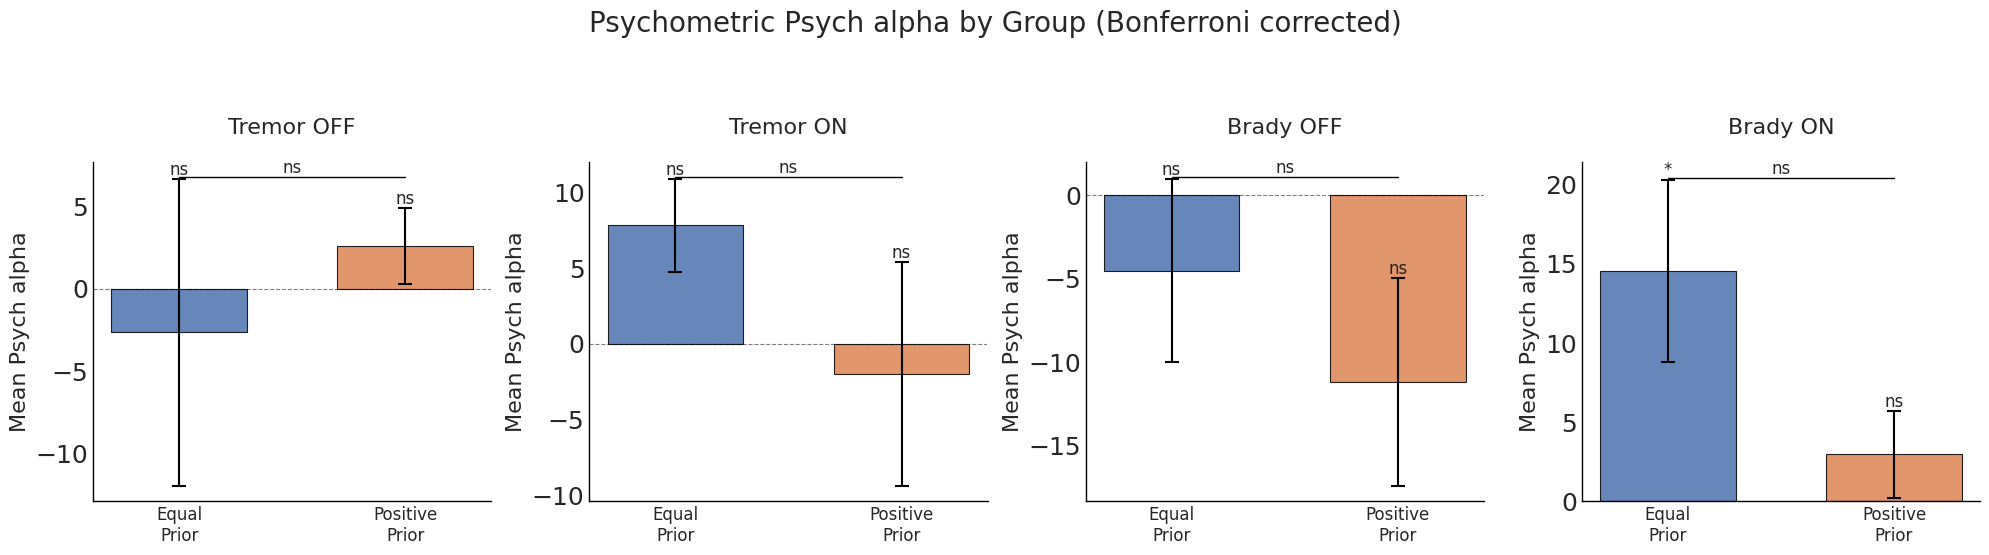

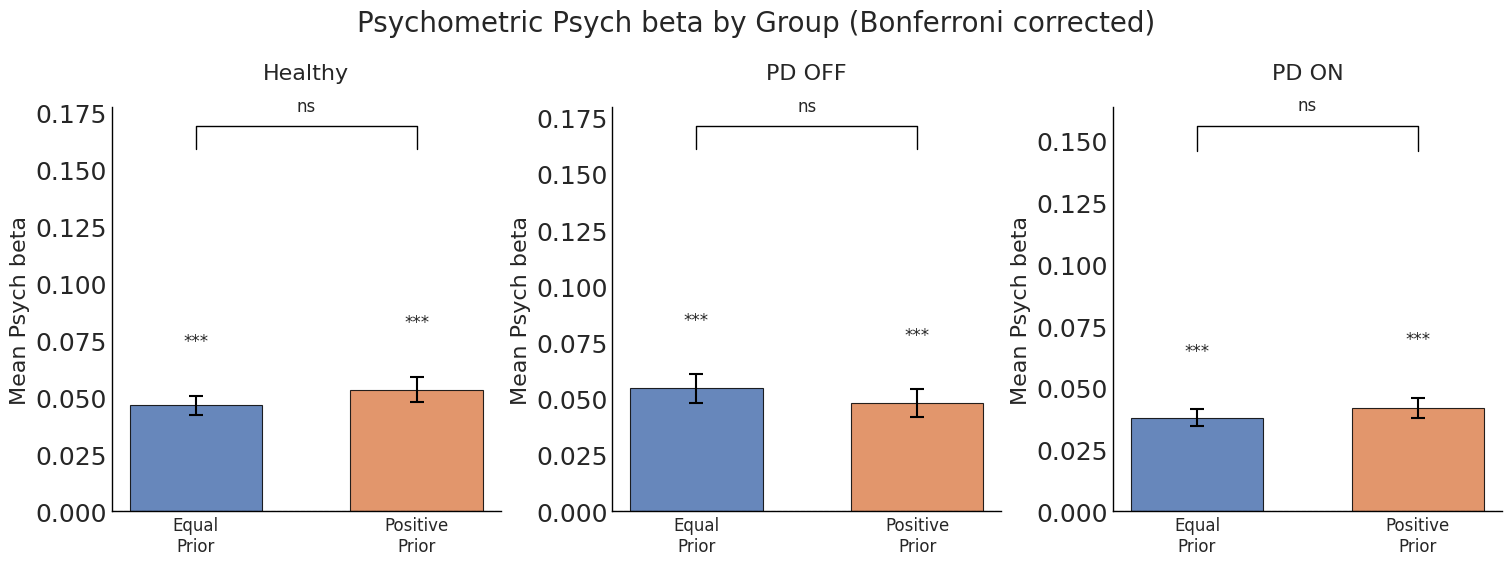

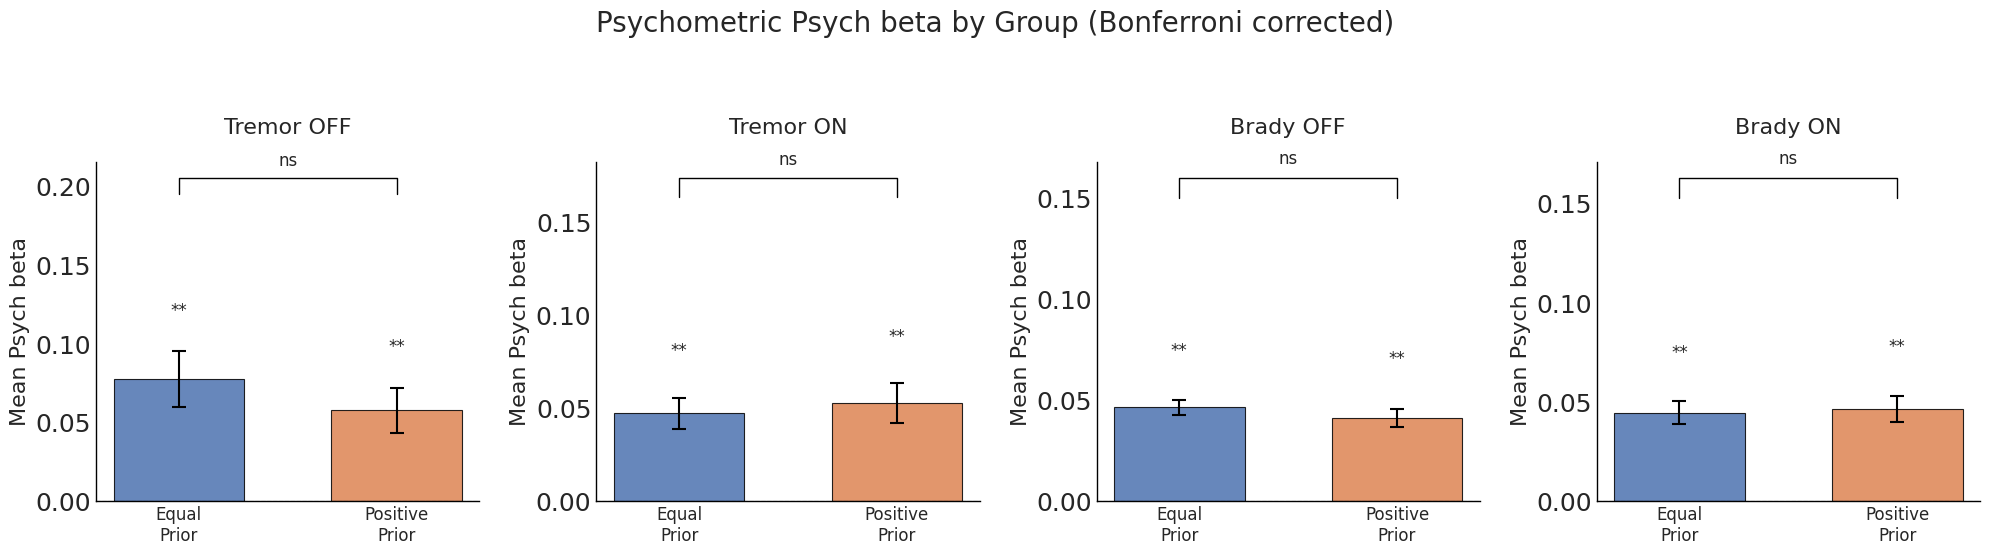

In [44]:
from src.utils.stats_utils import wilcoxon_battery
from scipy import stats as scipy_stats

test_labels = ["equal", "positive"]
test_xlabels = ["Equal\nPrior", "Positive\nPrior"]
bar_colors = ["#4C72B0", "#DD8452"]
bar_x = np.array([0, 1])

group_order = ["healthy", "pd_off", "pd_on", "tremor_off", "tremor_on", "brady_off", "brady_on"]
group_titles = {
    "healthy": "Healthy",
    "pd_off": "PD OFF",
    "pd_on": "PD ON",
    "tremor_off": "Tremor OFF",
    "tremor_on": "Tremor ON",
    "brady_off": "Brady OFF",
    "brady_on": "Brady ON",
}


for var in ["bias", "psych_alpha", "psych_beta"]:
    fig1, axes1 = plt.subplots(1, 3, figsize=(15, 5))
    fig2, axes2 = plt.subplots(1, 4, figsize=(20, 5))

    y_min, y_max = np.inf, -np.inf
    for grp in group_order:
        if grp in ["healthy", "pd_off", "pd_on"]:
            ax = axes1[["healthy", "pd_off", "pd_on"].index(grp)]
        else:
            ax = axes2[["tremor_off", "tremor_on", "brady_off", "brady_on"].index(grp)]
        group_data = psych_params.loc[grp_indices[grp]]
        pos_centered = group_data[f"positive_{var}"] if var != "bias" else group_data[f"positive_{var}"] - 0.5
        eq_centered = group_data[f"equal_{var}"] if var != "bias" else group_data[f"equal_{var}"] - 0.5

        results = wilcoxon_battery(
            tests={
                "equal": (eq_centered,),
                "positive": (pos_centered,),
                "positive_vs_equal": (group_data[f"positive_{var}"], group_data[f"equal_{var}"]),
            },
            print_results=False,
        ).set_index("test")

        diffs = {
            "equal": eq_centered,
            "positive": pos_centered,
        }

        bar_tops = {}
        for xi, (test_name, color) in enumerate(zip(test_labels, bar_colors)):
            vals = diffs[test_name].values
            mean = np.mean(vals)
            sem = scipy_stats.sem(vals)

            ax.bar(xi, mean, color=color, edgecolor="k", linewidth=0.8, width=0.6, alpha=0.85)
            ax.errorbar(xi, mean, yerr=sem, fmt="none", color="k", capsize=5, elinewidth=1.5, capthick=1.5)

            corr_p = results.loc[test_name, "corrected_p"]
            star = "***" if corr_p < 0.001 else "**" if corr_p < 0.01 else "*" if corr_p < 0.05 else "ns"
            ax.text(xi, mean + sem + 0.02, star, ha="center", va="bottom", fontsize=12)

            bar_tops[test_name] = mean + sem
            y_min = min(y_min, mean - sem)
            y_max = max(y_max, mean + sem + 0.08)

        bracket_y = max(bar_tops.values()) + 0.10
        p_vs_eq = results.loc["positive_vs_equal", "corrected_p"]
        p_str = "***" if p_vs_eq < 0.001 else "**" if p_vs_eq < 0.01 else "*" if p_vs_eq < 0.05 else "ns# p < 0.001" if p_vs_eq < 0.001 else "ns"  # f"p = {p_vs_eq:.3f}"
        ax.plot([0, 0, 1, 1], [bracket_y, bracket_y + 0.01, bracket_y + 0.01, bracket_y], color="k", lw=1)
        ax.text(0.5, bracket_y + 0.015, p_str, ha="center", va="bottom", fontsize=12)

        y_max = max(y_max, bracket_y + 0.06)

        ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.5)
        ax.set_xticks(bar_x)
        ax.set_xticklabels(test_xlabels, fontsize=12)
        ax.set_title(group_titles[grp], fontsize=16, pad=20)
        ax.set_ylabel(f"Mean {var.capitalize().replace('_', ' ')}")
        ax.grid(False)

    pad = (y_max - y_min) * 0.05
    for ax in axes:
        ax.set_ylim(y_min - pad, y_max + pad)

    fig1.suptitle(f"Psychometric {var.capitalize().replace('_', ' ')} by Group (Bonferroni corrected)", y=1.1, fontsize=20)
    fig2.suptitle(f"Psychometric {var.capitalize().replace('_', ' ')} by Group (Bonferroni corrected)", y=1.1, fontsize=20)
    plt.tight_layout()
    plt.show()
